In [1]:
import sys                                                  # Read system parameters.
import numpy as np                                          # Work with multi-dimensional arrays.
import pandas as pd                                         # Manipulate and analyze data.
import scipy as sp                                          # Apply advanced mathematical functions.
from scipy import stats
import matplotlib                                           # Create and format charts.
import matplotlib.pyplot as plt  
import seaborn as sns                                       # Make charting easier.
import sklearn                                              # Train and evaluate machine learning models.
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import category_encoders as ce                              # Encode data.
import warnings                                             # Suppress warnings.
warnings.filterwarnings('ignore')


#Load and preview the data
users_data = pd.read_pickle('users_data_cleaned.pickle')
users_data.head(n = 5)


,user_id,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,term_deposit,date_joined,device
0,9231c446-cb16-4b2b-a7f7-ddfc8b25aaf6,3.0,2143.0,58,management,married,tertiary,False,True,False,None,261,1,-1,0,None,False,1998-08-23,mobile
1,bb92765a-08de-4963-b432-496524b39157,NaN,NaN,44,technician,single,secondary,False,True,False,None,151,1,-1,0,None,False,2008-07-15,desktop
2,573de577-49ef-42b9-83da-d3cfb817b5c1,2.0,2.0,33,entrepreneur,married,secondary,False,True,True,None,76,1,-1,0,None,False,2002-06-04,mobile
3,d6b66b9d-7c8f-4257-a682-e136f640b7e3,NaN,NaN,47,blue-collar,married,None,False,True,False,None,92,1,-1,0,None,False,1995-06-29,tablet
4,fade0b20-7594-4d9a-84cd-c02f79b1b526,1.0,1.0,33,None,single,None,False,False,False,None,198,1,-1,0,None,False,1995-08-01,mobile


In [2]:
#Check the shape of the data
users_data.shape

(45209, 19)

In [3]:
#Check the number of unique users
len(np.unique(users_data.user_id))

45209

In [4]:
#Check the data types
users_data.info()
users_data.columns.to_series().groupby(users_data.dtypes).groups

<class 'pandas.core.frame.DataFrame'>
Index: 45209 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45209 non-null  object        
 1   number_transactions  35210 non-null  float64       
 2   total_amount_usd     35210 non-null  float64       
 3   age                  45209 non-null  int64         
 4   job                  44921 non-null  object        
 5   marital              45209 non-null  object        
 6   education            43352 non-null  object        
 7   default              45209 non-null  bool          
 8   housing              45209 non-null  bool          
 9   loan                 45209 non-null  bool          
 10  contact              32191 non-null  object        
 11  duration             45209 non-null  int64         
 12  campaign             45209 non-null  int64         
 13  pdays                45209 non-null 

{bool: ['default', 'housing', 'loan', 'term_deposit'], int64: ['age', 'duration', 'campaign', 'pdays', 'previous'], float64: ['number_transactions', 'total_amount_usd'], datetime64[ns]: ['date_joined'], object: ['user_id', 'job', 'marital', 'education', 'contact', 'poutcome', 'device']}

In [5]:
#Check for correlations
users_data.corr(numeric_only = True).abs()

,number_transactions,total_amount_usd,age,default,housing,loan,duration,campaign,pdays,previous,term_deposit
number_transactions,1.000000,0.163409,0.008813,0.138838,0.030429,0.075319,0.017220,0.026431,0.030751,0.023046,0.053390
total_amount_usd,0.163409,1.000000,0.095839,0.065390,0.066857,0.084526,0.022586,0.017274,0.006435,0.016952,0.050785
age,0.008813,0.095839,1.000000,0.017875,0.185552,0.015641,0.004645,0.004767,0.023745,0.001297,0.025168
default,0.138838,0.065390,0.017875,1.000000,0.006020,0.077232,0.010017,0.016819,0.029982,0.018331,0.022421
housing,0.030429,0.066857,0.185552,0.006020,1.000000,0.041341,0.005041,0.023583,0.124197,0.037087,0.139161
loan,0.075319,0.084526,0.015641,0.077232,0.041341,1.000000,0.012395,0.009972,0.022762,0.011048,0.068193
duration,0.017220,0.022586,0.004645,0.010017,0.005041,0.012395,1.000000,0.084551,0.001549,0.001213,0.394549
campaign,0.026431,0.017274,0.004767,0.016819,0.023583,0.009972,0.084551,1.000000,0.088636,0.032860,0.073179
pdays,0.030751,0.006435,0.023745,0.029982,0.124197,0.022762,0.001549,0.088636,1.000000,0.454817,0.103616
previous,0.023046,0.016952,0.001297,0.018331,0.037087,0.011048,0.001213,0.032860,0.454817,1.000000,0.093232


In [6]:
#Generate summary statistics for all of the data
users_data.describe(include = 'all')

,user_id,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,term_deposit,date_joined,device
count,45209,35210.000000,35210.000000,45209.000000,44921,45209,43352,45209,45209,45209,32191,45209.000000,45209.000000,45209.000000,45209.000000,8252,45209,45179,45115
unique,45209,NaN,NaN,NaN,11,3,3,2,2,2,2,NaN,NaN,NaN,NaN,3,2,NaN,3
top,5905741c-3f30-416f-8ee5-71abad035de6,NaN,NaN,NaN,blue-collar,married,secondary,False,True,False,cellular,NaN,NaN,NaN,NaN,failure,False,NaN,mobile
freq,1,NaN,NaN,NaN,9731,27212,23202,44394,25128,37965,29285,NaN,NaN,NaN,NaN,4901,39920,NaN,27504
mean,NaN,3.977052,1369.417751,40.935853,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258.153067,2.763897,40.199651,0.580349,NaN,NaN,1999-06-14 21:54:38.558622336,NaN
min,NaN,1.000000,-8019.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN,1988-01-01 00:00:00,NaN
25%,NaN,2.000000,73.000000,33.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN,1993-09-18 00:00:00,NaN
50%,NaN,3.000000,451.000000,39.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN,1999-06-11 00:00:00,NaN
75%,NaN,4.000000,1438.000000,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN,2005-03-18 00:00:00,NaN
max,NaN,20.000000,102127.000000,95.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4918.000000,63.000000,871.000000,275.000000,NaN,NaN,2010-11-30 00:00:00,NaN


In [7]:
#Generate summary statistics for numerical data only
users_data.describe(include = np.number)

,number_transactions,total_amount_usd,age,duration,campaign,pdays,previous
count,35210.000000,35210.000000,45209.000000,45209.000000,45209.000000,45209.000000,45209.000000
mean,3.977052,1369.417751,40.935853,258.153067,2.763897,40.199651,0.580349
std,3.814329,3063.412688,10.618653,257.525446,3.098076,100.130586,2.303489
min,1.000000,-8019.000000,18.000000,0.000000,1.000000,-1.000000,0.000000
25%,2.000000,73.000000,33.000000,103.000000,1.000000,-1.000000,0.000000
50%,3.000000,451.000000,39.000000,180.000000,2.000000,-1.000000,0.000000
75%,4.000000,1438.000000,48.000000,319.000000,3.000000,-1.000000,0.000000
max,20.000000,102127.000000,95.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
#Generate modal values for all data
# Drop user ID since it's unique.

users_data.drop(['user_id'], axis = 1).mode()


,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,term_deposit,date_joined,device
0,2.0,0.0,32.0,blue-collar,married,secondary,False,True,False,cellular,124.0,1.0,-1.0,0.0,failure,False,1990-07-05,mobile
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2007-12-07,NaN


In [9]:
#Generate skewness and kurtosis measurements
users_data.skew(numeric_only = True)
users_data.kurt(numeric_only = True)

number_transactions       6.659034
total_amount_usd        150.790967
age                       0.319760
default                  50.495241
housing                  -1.949602
loan                      1.431987
duration                 18.155941
campaign                 39.248145
pdays                     6.934713
previous               4506.684640
term_deposit              3.680770
dtype: float64

array([[<Axes: title={'center': 'number_transactions'}>,
        <Axes: title={'center': 'total_amount_usd'}>,
        <Axes: title={'center': 'age'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>, <Axes: >, <Axes: >]],
      dtype=object)

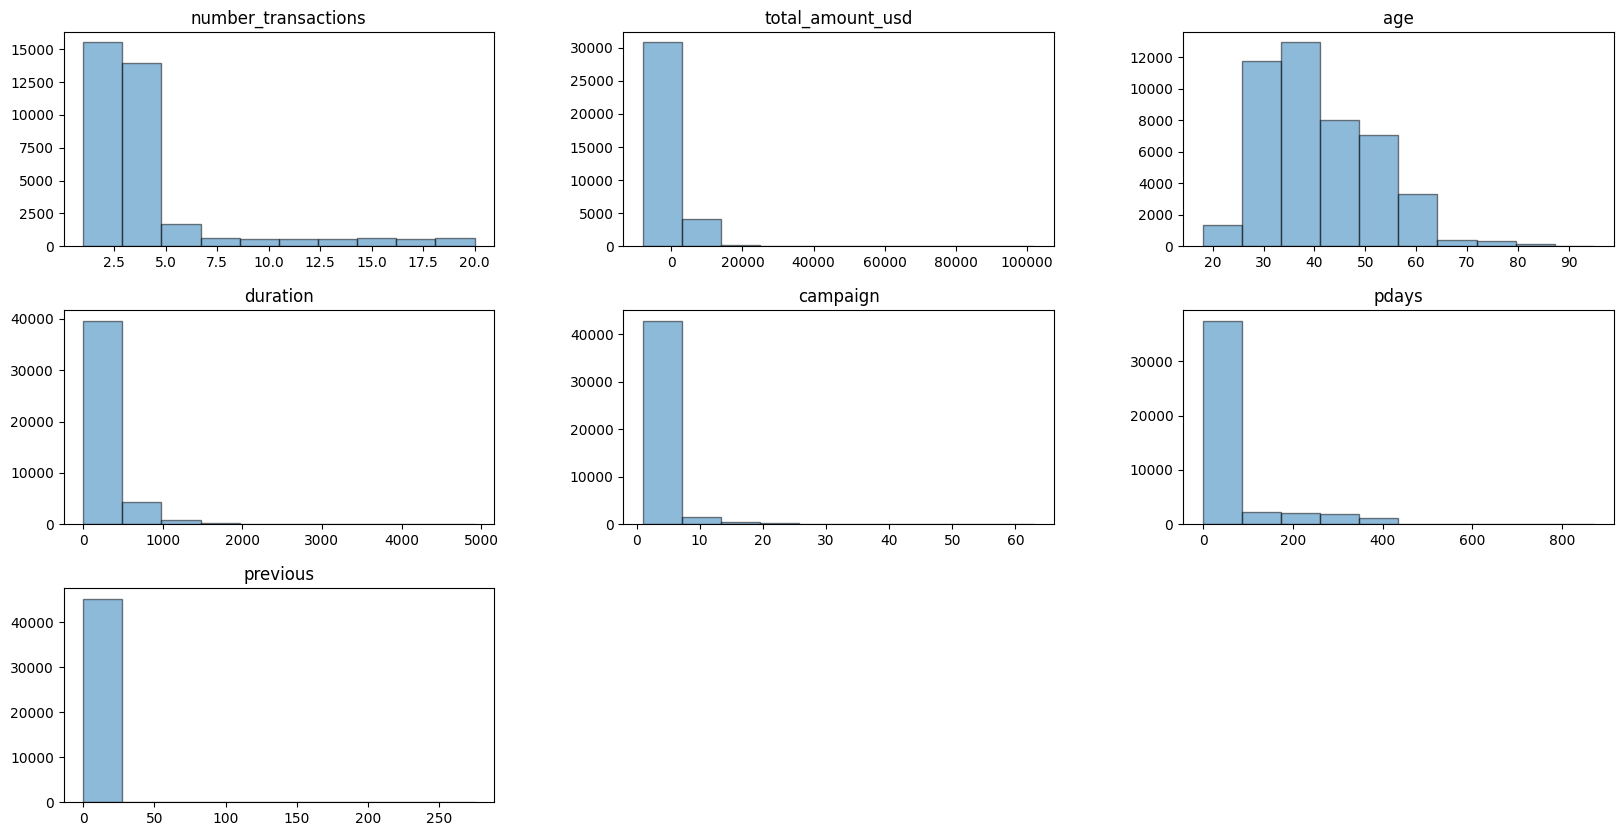

In [10]:

#Plot histograms for all numerical columns
users_data_for_hist = \
users_data.select_dtypes(exclude = ['bool', 'datetime64[ns]'])

users_data_for_hist.hist(figsize = (20, 10), alpha = 0.5,
                         edgecolor = 'black', grid = False)

'\n1. Komponen dalam Boxplot\nBoxplot terdiri daripada beberapa elemen utama:\n\nKotak (Box): Menunjukkan julat antara kuartil pertama (Q1, 25%) dan kuartil ketiga (Q3, 75%).\n\nGaris dalam kotak (Median Line): Garis tengah menunjukkan median (Q2, 50%).\n\nMisai (Whiskers): Had luar whiskers biasanya ditentukan oleh IQR (Interquartile Range), yang dikira sebagai:\n\nIQR=𝑄3−𝑄1\nHad luar whiskers:\n\nBawah: \n𝑄1−1.5×IQR\n\nAtas: \n𝑄3+1.5×IQR\n\nNilai yang berada di luar had ini dianggap sebagai outlier.\n\nTitik Bulat (Outliers): Titik di luar whiskers mewakili data outlier.\n\n\n2. Interpretasi Boxplot\nMedian (Garis dalam kotak)\nMedian umur kelihatan berada sekitar 40 tahun.\nJulat Umur\nJulat interkuartil (Q1 ke Q3) berkisar antara 30 hingga 50 tahun.\nOutliers\nTerdapat banyak outliers di sebelah kanan (umur lebih daripada 70 tahun).\nIni menunjukkan bahawa terdapat beberapa individu yang jauh lebih tua berbanding majoriti populasi.\nSifat Data\nSkewed ke kanan (Right-skewed) kerana

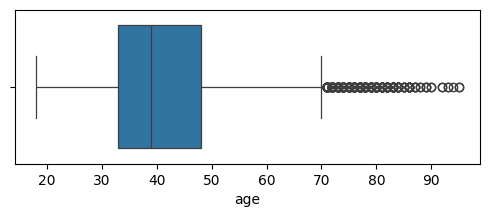

In [11]:
#Generate a box plot for age
users_data['age'].describe()

plt.figure(figsize = (6, 2))
sns.boxplot(x = users_data['age'], linewidth = 0.9);


"""
1. Komponen dalam Boxplot
Boxplot terdiri daripada beberapa elemen utama:

Kotak (Box): Menunjukkan julat antara kuartil pertama (Q1, 25%) dan kuartil ketiga (Q3, 75%).

Garis dalam kotak (Median Line): Garis tengah menunjukkan median (Q2, 50%).

Misai (Whiskers): Had luar whiskers biasanya ditentukan oleh IQR (Interquartile Range), yang dikira sebagai:

IQR=𝑄3−𝑄1
Had luar whiskers:

Bawah: 
𝑄1−1.5×IQR

Atas: 
𝑄3+1.5×IQR

Nilai yang berada di luar had ini dianggap sebagai outlier.

Titik Bulat (Outliers): Titik di luar whiskers mewakili data outlier.


2. Interpretasi Boxplot
Median (Garis dalam kotak)
Median umur kelihatan berada sekitar 40 tahun.
Julat Umur
Julat interkuartil (Q1 ke Q3) berkisar antara 30 hingga 50 tahun.
Outliers
Terdapat banyak outliers di sebelah kanan (umur lebih daripada 70 tahun).
Ini menunjukkan bahawa terdapat beberapa individu yang jauh lebih tua berbanding majoriti populasi.
Sifat Data
Skewed ke kanan (Right-skewed) kerana terdapat lebih banyak outliers di sebelah kanan.
Ini menunjukkan bahawa sebilangan kecil individu mempunyai umur yang lebih tinggi daripada kebanyakan populasi.


3. Tindakan Berdasarkan Boxplot
Jika anda sedang melakukan analisis data, anda mungkin mahu:

Menangani outliers:
Jika data umur mewakili realiti (contohnya umur manusia yang sememangnya boleh mencapai 90 tahun), outliers boleh dikekalkan.
Jika umur lebih daripada had tertentu adalah kesilapan data (contohnya umur 200 tahun), anda mungkin perlu membuang atau membetulkannya.
Menggunakan transformasi data:
Jika analisis memerlukan data yang lebih normal, anda boleh menggunakan log transformation atau standardization untuk mengurangkan skewness.

Kesimpulan
Kebanyakan individu berada dalam julat umur 30 hingga 50 tahun.
Outliers menunjukkan beberapa individu berumur lebih daripada 70 tahun.
Data ini right-skewed, yang bermaksud terdapat beberapa individu yang jauh lebih tua daripada majoriti populasi.

"""

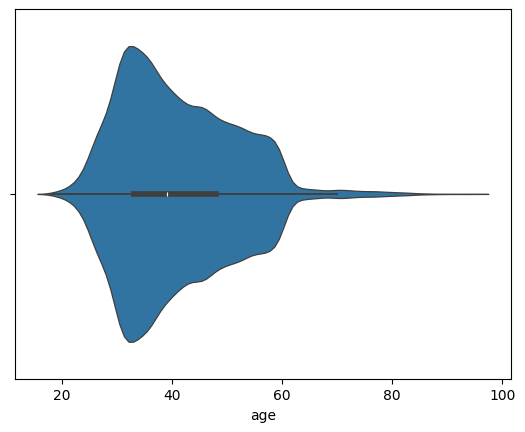

In [12]:
#Generate a violin plot for age
sns.violinplot(x = users_data['age'], linewidth = 0.9);

In [13]:
#Generate a box plot for number_transactions
users_data['number_transactions'].describe()

count    35210.000000
mean         3.977052
std          3.814329
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         20.000000
Name: number_transactions, dtype: float64

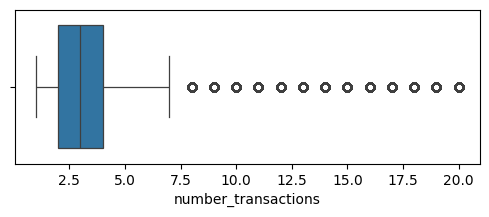

In [14]:
plt.figure(figsize = (6, 2))
sns.boxplot(x = users_data['number_transactions'],
            linewidth = 0.9);

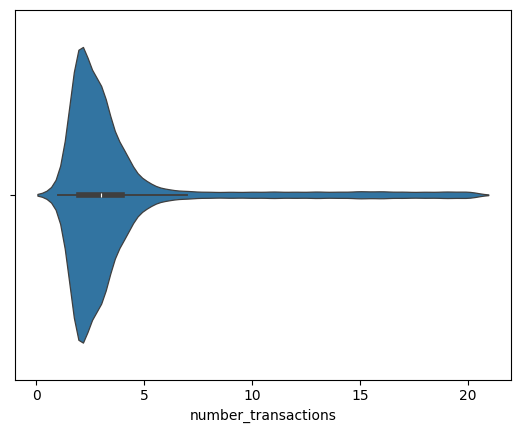

In [15]:
#Generate a violin plot for number_transactions
sns.violinplot(x = users_data['number_transactions'],
               linewidth=0.9);

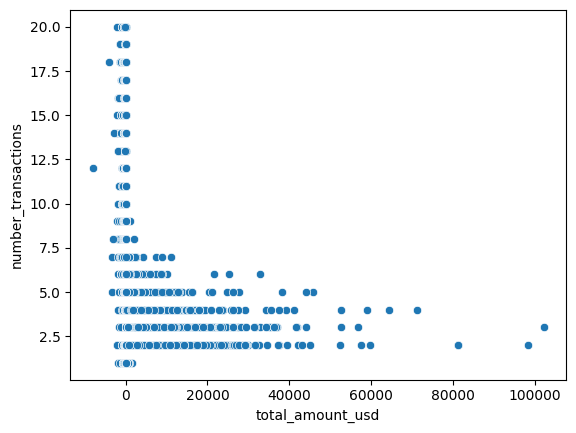

In [16]:
#Generate scatter plots comparing total_amount_usd to number_transactions
sns.scatterplot(data = users_data, x = 'total_amount_usd',
                y = 'number_transactions');

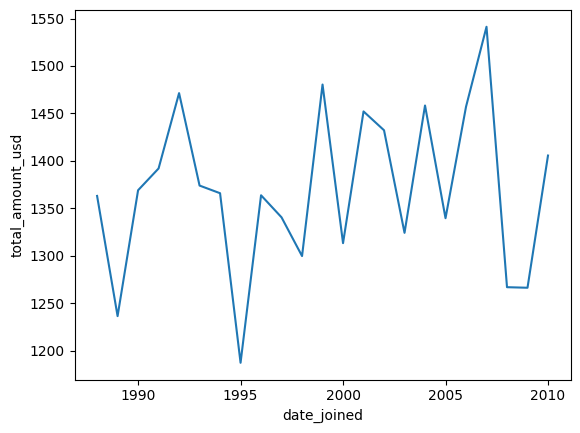

In [17]:
#Generate a line plot for total_amount_usd
years = users_data['date_joined'].dt.year

sns.lineplot(data = users_data, x = years,
             y = 'total_amount_usd',
             estimator = np.mean,
             errorbar = None);

In [18]:
#Generate bar charts for job
users_job_dist = \
users_data['job'].value_counts(dropna = False)

users_job_dist

job
blue-collar      9731
management       9457
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
None              288
Name: count, dtype: int64

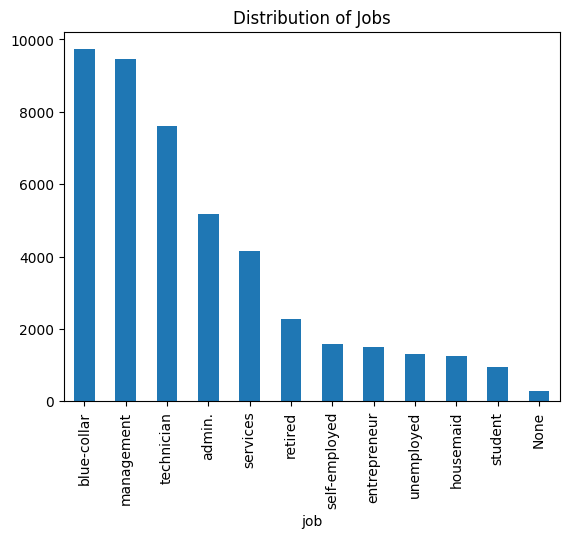

In [19]:
# Vertical bar chart.

users_job_dist.plot(kind = 'bar')
plt.title('Distribution of Jobs');

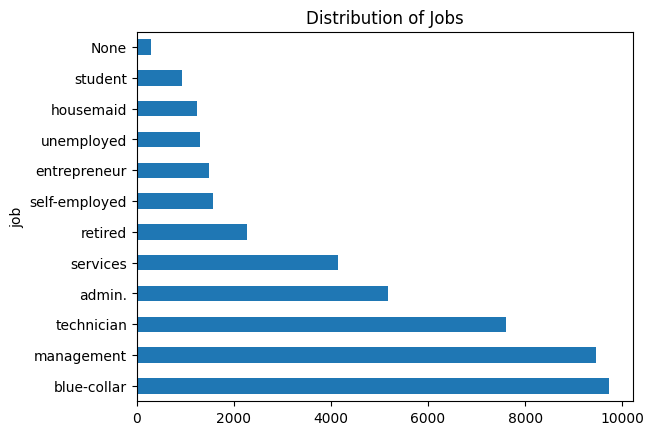

In [20]:
# Horizontal bar chart

users_job_dist.plot(kind = 'barh')
plt.title('Distribution of Jobs');

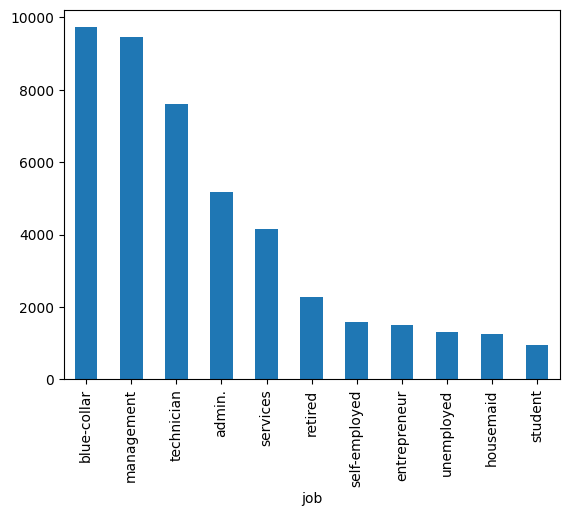

In [21]:
# Exclude missing values.

users_data['job'].value_counts().plot(kind = 'bar');

In [22]:
#Generate a bar chart for marital
users_marital_dist = \
users_data['marital'].value_counts(dropna = False)

users_marital_dist

marital
married     27212
single      12790
divorced     5207
Name: count, dtype: int64

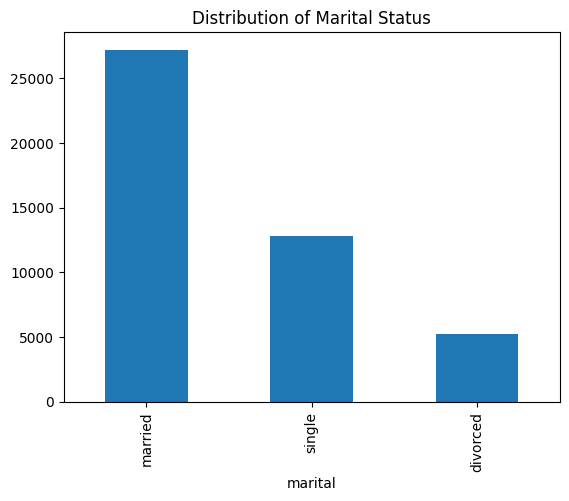

In [23]:
users_marital_dist.plot(kind = 'bar')
plt.title('Distribution of Marital Status');

In [24]:
#Generate a bar chart for education
users_education_dist = \
users_data['education'].value_counts(dropna = False)

users_education_dist

education
secondary    23202
tertiary     13300
primary       6850
None          1857
Name: count, dtype: int64

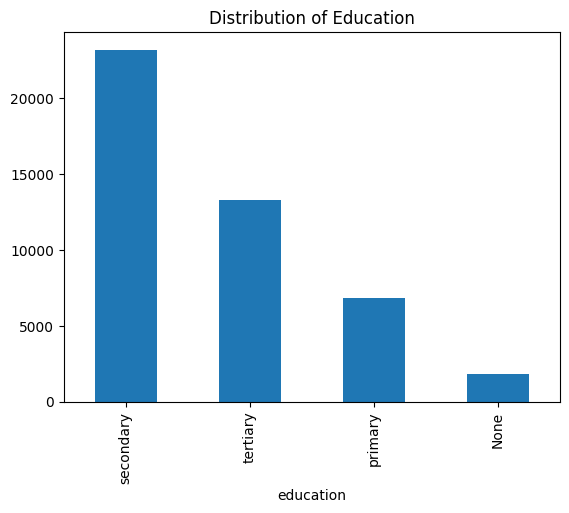

In [25]:
users_education_dist.plot(kind = 'bar')
plt.title('Distribution of Education');

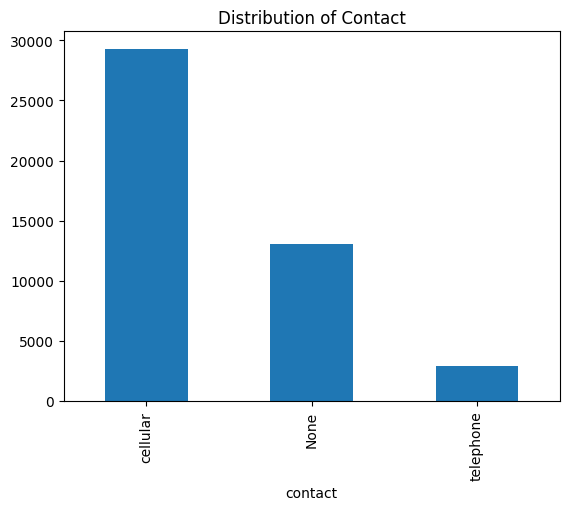

In [26]:
#Generate a bar chart for contact
users_contact_dist = \
users_data['contact'].value_counts(dropna = False)

users_contact_dist.plot(kind = 'bar')
plt.title('Distribution of Contact');

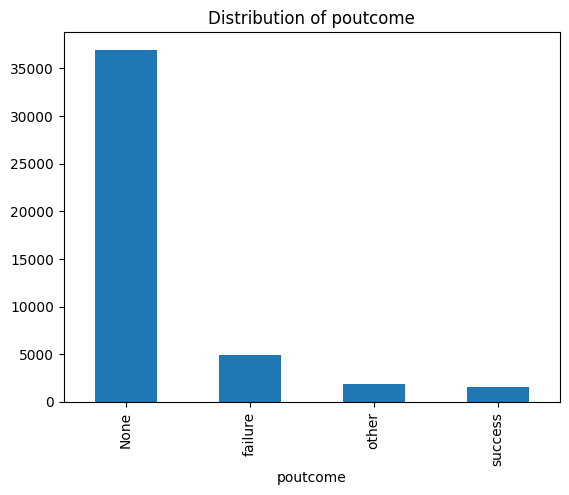

In [27]:
#Generate a bar chart for poutcome
users_poutcome_dist = \
users_data['poutcome'].value_counts(dropna = False)

users_poutcome_dist.plot(kind = 'bar')
plt.title('Distribution of poutcome');

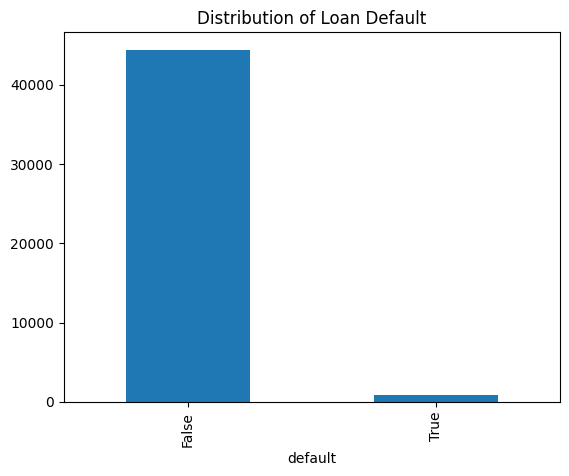

In [28]:
#Generate a bar chart for default
users_default_dist = \
users_data['default'].value_counts(dropna = False)

users_default_dist.plot(kind = 'bar')
plt.title('Distribution of Loan Default');

In [29]:
#Generate a bar chart for device
users_device_dist = \
users_data['device'].value_counts(dropna = False)

users_device_dist

device
mobile     27504
desktop    12112
tablet      5499
None          94
Name: count, dtype: int64

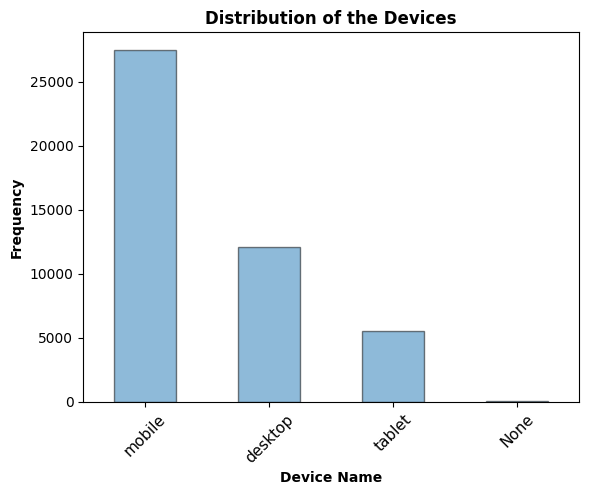

In [30]:
users_device_dist.plot(kind = 'bar',
                       alpha = 0.5, edgecolor = 'black')
plt.title('Distribution of the Devices',
          size = 12, weight = 'bold')
plt.xticks(rotation = 45, size = 11)
plt.xlabel('Device Name', size = 10, weight = 'bold')
plt.ylabel('Frequency', size = 10, weight = 'bold')
plt.show();

In [31]:
#Generate a heatmap for the feature correlations
corr_matrix = users_data.corr(numeric_only = True)

corr_matrix

,number_transactions,total_amount_usd,age,default,housing,loan,duration,campaign,pdays,previous,term_deposit
number_transactions,1.000000,-0.163409,-0.008813,0.138838,0.030429,0.075319,-0.017220,0.026431,-0.030751,-0.023046,-0.053390
total_amount_usd,-0.163409,1.000000,0.095839,-0.065390,-0.066857,-0.084526,0.022586,-0.017274,0.006435,0.016952,0.050785
age,-0.008813,0.095839,1.000000,-0.017875,-0.185552,-0.015641,-0.004645,0.004767,-0.023745,0.001297,0.025168
default,0.138838,-0.065390,-0.017875,1.000000,-0.006020,0.077232,-0.010017,0.016819,-0.029982,-0.018331,-0.022421
housing,0.030429,-0.066857,-0.185552,-0.006020,1.000000,0.041341,0.005041,-0.023583,0.124197,0.037087,-0.139161
loan,0.075319,-0.084526,-0.015641,0.077232,0.041341,1.000000,-0.012395,0.009972,-0.022762,-0.011048,-0.068193
duration,-0.017220,0.022586,-0.004645,-0.010017,0.005041,-0.012395,1.000000,-0.084551,-0.001549,0.001213,0.394549
campaign,0.026431,-0.017274,0.004767,0.016819,-0.023583,0.009972,-0.084551,1.000000,-0.088636,-0.032860,-0.073179
pdays,-0.030751,0.006435,-0.023745,-0.029982,0.124197,-0.022762,-0.001549,-0.088636,1.000000,0.454817,0.103616
previous,-0.023046,0.016952,0.001297,-0.018331,0.037087,-0.011048,0.001213,-0.032860,0.454817,1.000000,0.093232


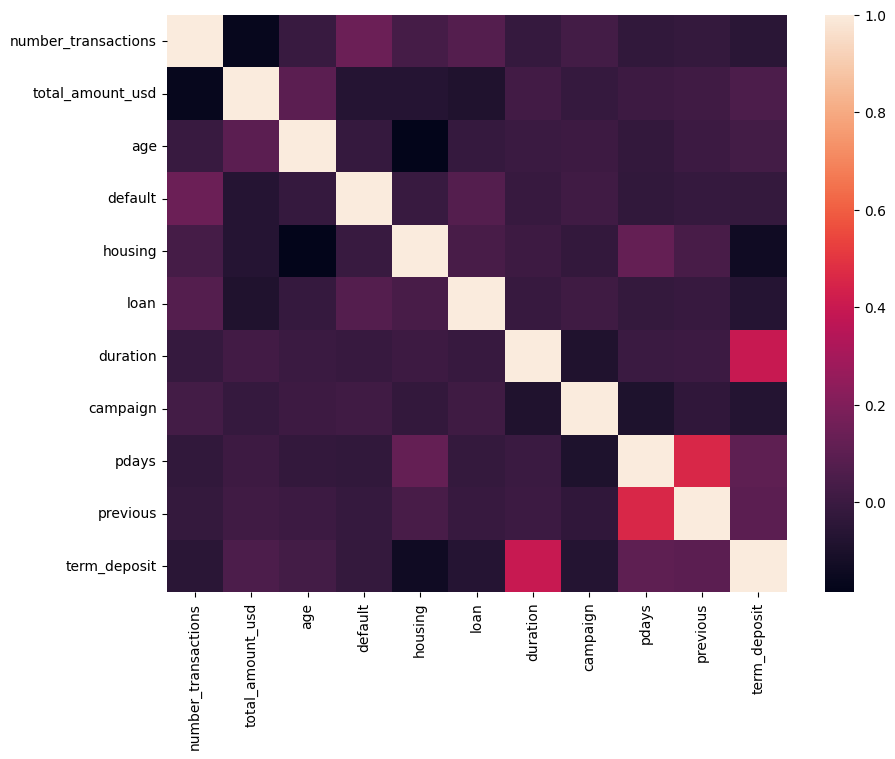

In [32]:
fig = plt.figure(figsize = (10, 7.5))

sns.heatmap(corr_matrix);

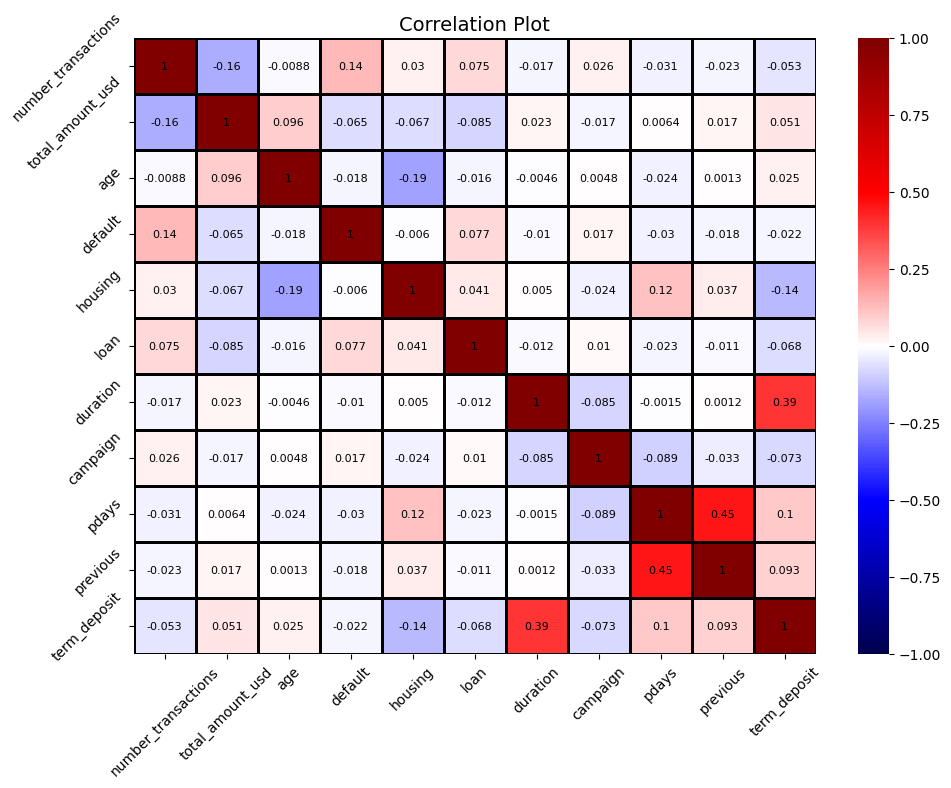

In [33]:
#Format the heatmap to make it easier to read
fig = plt.figure(figsize = (11, 8))

sns.heatmap(corr_matrix, 
            cmap = 'seismic', 
            linewidth = 0.75,
            linecolor = 'black',
            cbar = True,
            vmin = -1, 
            vmax = 1,
            annot = True,
            annot_kws = {'size': 8, 'color': 'black'})

plt.tick_params(labelsize = 10, rotation = 45)
plt.title('Correlation Plot', size = 14);

In [34]:
#Identify missing values 
users_data.isnull().sum()

user_id                    0
number_transactions     9999
total_amount_usd        9999
age                        0
job                      288
marital                    0
education               1857
default                    0
housing                    0
loan                       0
contact                13018
duration                   0
campaign                   0
pdays                      0
previous                   0
poutcome               36957
term_deposit               0
date_joined               30
device                    94
dtype: int64

In [35]:
#Identify the percentage of missing values for each feature
percent_missing = users_data.isnull().mean() 

percent_missing

user_id                0.000000
number_transactions    0.221173
total_amount_usd       0.221173
age                    0.000000
job                    0.006370
marital                0.000000
education              0.041076
default                0.000000
housing                0.000000
loan                   0.000000
contact                0.287952
duration               0.000000
campaign               0.000000
pdays                  0.000000
previous               0.000000
poutcome               0.817470
term_deposit           0.000000
date_joined            0.000664
device                 0.002079
dtype: float64

In [36]:
#Generate a missing-value report
def missing_value_pct_df(data):
    """Create a data frame to summarize missing values."""
  
    percent_missing = data.isnull().mean() 
    missing_value_df = \
    pd.DataFrame(percent_missing).reset_index()
    
    missing_value_df = \
    missing_value_df.rename(columns = {'index': 'column_name',
                                       0: 'percent_missing'})

    # Multiply by 100 and round to 4 decimal places.
    missing_value_df['percent_missing'] = \
    missing_value_df['percent_missing']. \
    apply(lambda x: round(x * 100, 2)) 

    missing_value_df = \
    missing_value_df.sort_values(by = ['percent_missing'],
                                 ascending = False)

    return missing_value_df

In [37]:
missing_value_df = missing_value_pct_df(users_data)

missing_value_df

,column_name,percent_missing
15,poutcome,81.75
10,contact,28.80
1,number_transactions,22.12
2,total_amount_usd,22.12
6,education,4.11
4,job,0.64
18,device,0.21
17,date_joined,0.07
0,user_id,0.00
5,marital,0.00


In [38]:
#Remove features with a high percentage of missing values

# Threshold above which to drop feature.

threshold = 80

cols_to_drop = \
list(missing_value_df[missing_value_df['percent_missing'] \
                      > threshold]['column_name'])

print('Number of features to drop:',
      missing_value_df[ \
      missing_value_df['percent_missing'] > threshold].shape[0])

print(f'Features with missing values greater than {threshold}%:',
      cols_to_drop)

Number of features to drop: 1
Features with missing values greater than 80%: ['poutcome']


In [39]:
users_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45209 entries, 0 to 45215
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45209 non-null  object        
 1   number_transactions  35210 non-null  float64       
 2   total_amount_usd     35210 non-null  float64       
 3   age                  45209 non-null  int64         
 4   job                  44921 non-null  object        
 5   marital              45209 non-null  object        
 6   education            43352 non-null  object        
 7   default              45209 non-null  bool          
 8   housing              45209 non-null  bool          
 9   loan                 45209 non-null  bool          
 10  contact              32191 non-null  object        
 11  duration             45209 non-null  int64         
 12  campaign             45209 non-null  int64         
 13  pdays                45209 non-null 

In [40]:
users_data_cleaned = users_data.drop(cols_to_drop, axis = 1)
users_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45209 entries, 0 to 45215
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              45209 non-null  object        
 1   number_transactions  35210 non-null  float64       
 2   total_amount_usd     35210 non-null  float64       
 3   age                  45209 non-null  int64         
 4   job                  44921 non-null  object        
 5   marital              45209 non-null  object        
 6   education            43352 non-null  object        
 7   default              45209 non-null  bool          
 8   housing              45209 non-null  bool          
 9   loan                 45209 non-null  bool          
 10  contact              32191 non-null  object        
 11  duration             45209 non-null  int64         
 12  campaign             45209 non-null  int64         
 13  pdays                45209 non-null 

In [41]:
# Confirm feature was dropped.

missing_value_df = missing_value_pct_df(users_data_cleaned)

missing_columns = \
list(missing_value_df[missing_value_df['percent_missing'] \
                      > 0]['column_name'])
print(missing_columns)
print('Number of features with missing values:',
      len(missing_columns))

['contact', 'number_transactions', 'total_amount_usd', 'education', 'job', 'device', 'date_joined']
Number of features with missing values: 7


In [42]:
#Identify numerical data with missing values
dtypes = ['int64', 'float64']

numerical_columns = \
list(users_data_cleaned.select_dtypes(dtypes).columns)

print('Numerical features with missing values:',
      list(set(numerical_columns).intersection(missing_columns)))

Numerical features with missing values: ['number_transactions', 'total_amount_usd']


In [43]:
#Impute missing data values for total_amount_usd
# Find a sample user with missing value.

sample_user = \
users_data_cleaned[users_data_cleaned['total_amount_usd']. \
                   isnull()].sample(1).user_id

sample_user



44046    284279c5-e984-4274-be31-8c04b2033f93
Name: user_id, dtype: object

In [44]:
#print(users_data_cleaned[users_data_cleaned.user_id=='415939e3-aca2-4ffd-bc78-3d699cad576a'])
#users_data_cleaned[users_data_cleaned.user_id=='602a3ab8-4d6b-4877-b74e-74e39d54560f']
#users_data_cleaned[users_data_cleaned.user_id=='e8da65ff-b3b9-4d3e-9bbb-85861214c856']

print(users_data_cleaned['total_amount_usd'].isnull().value_counts())
print(f'total null in column total_amount_usd-{users_data_cleaned['total_amount_usd'].isnull().sum()}')

total_amount_usd
False    35210
True      9999
Name: count, dtype: int64
total null in column total_amount_usd-9999


In [45]:
users_data_cleaned[users_data_cleaned.user_id=='602a3ab8-4d6b-4877-b74e-74e39d54560f']

,user_id,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,term_deposit,date_joined,device
32236,602a3ab8-4d6b-4877-b74e-74e39d54560f,NaN,NaN,31,technician,single,tertiary,False,True,False,cellular,60,1,342,1,False,1995-02-08,mobile


In [46]:
# Print mean of total_amount_usd.

print('Mean total_amount_usd:',
      round(users_data_cleaned['total_amount_usd'].mean(), 2))

# Impute missing values for total_amount_usd with mean.

users_data_cleaned['total_amount_usd']. \
fillna(round(users_data_cleaned['total_amount_usd'].mean(), 2), 
       inplace = True)

Mean total_amount_usd: 1369.42


In [47]:
users_data_cleaned[users_data_cleaned.user_id=='602a3ab8-4d6b-4877-b74e-74e39d54560f']

,user_id,number_transactions,total_amount_usd,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,term_deposit,date_joined,device
32236,602a3ab8-4d6b-4877-b74e-74e39d54560f,NaN,1369.42,31,technician,single,tertiary,False,True,False,cellular,60,1,342,1,False,1995-02-08,mobile


In [48]:
print(users_data_cleaned['total_amount_usd'].isnull().value_counts())
print(f'total null in column total_amount_usd-{users_data_cleaned['total_amount_usd'].isnull().sum()}')

total_amount_usd
False    45209
Name: count, dtype: int64
total null in column total_amount_usd-0


In [49]:
users_data_cleaned[users_data_cleaned. \
                   user_id.isin(sample_user)]['total_amount_usd']

44046    1369.42
Name: total_amount_usd, dtype: float64

In [50]:
users_data_cleaned.number_transactions.value_counts()

number_transactions
2.0     14853
3.0      9909
4.0      4010
5.0      1223
1.0       662
6.0       500
7.0       337
15.0      324
16.0      315
20.0      300
19.0      294
13.0      294
11.0      294
17.0      277
14.0      272
10.0      272
12.0      271
18.0      270
9.0       268
8.0       265
Name: count, dtype: int64

In [51]:

#Replace missing values for number_transactions with 0
users_data_cleaned['number_transactions']. \
fillna(0, inplace = True)

In [52]:
users_data_cleaned[users_data_cleaned. \
                   user_id.isin(sample_user)]['number_transactions']

44046    0.0
Name: number_transactions, dtype: float64

In [53]:
users_data_cleaned.number_transactions.value_counts()

number_transactions
2.0     14853
0.0      9999
3.0      9909
4.0      4010
5.0      1223
1.0       662
6.0       500
7.0       337
15.0      324
16.0      315
20.0      300
19.0      294
13.0      294
11.0      294
17.0      277
14.0      272
10.0      272
12.0      271
18.0      270
9.0       268
8.0       265
Name: count, dtype: int64

In [54]:
#Identify categorical data with missing values
categorical_columns = \
list(users_data_cleaned.select_dtypes(['object']).columns)

print('Categorical features with missing values:',
      list(set(categorical_columns).intersection(missing_columns)))

Categorical features with missing values: ['contact', 'job', 'education', 'device']


In [55]:
users_data_cleaned.contact.value_counts()

contact
cellular     29285
telephone     2906
Name: count, dtype: int64

In [56]:
users_data_cleaned.device.value_counts()

device
mobile     27504
desktop    12112
tablet      5499
Name: count, dtype: int64

In [57]:
users_data_cleaned.education.value_counts()

education
secondary    23202
tertiary     13300
primary       6850
Name: count, dtype: int64

In [58]:
users_data_cleaned.job.value_counts()

job
blue-collar      9731
management       9457
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Name: count, dtype: int64

In [59]:
#Replace categorical missing values with 'Unknown'
users_data_cleaned.device.fillna('Unknown', inplace = True)
users_data_cleaned.education.fillna('Unknown', inplace = True)
users_data_cleaned.contact.fillna('Unknown', inplace = True)
users_data_cleaned.job.fillna('Unknown', inplace = True)

In [60]:
users_data_cleaned.job.value_counts()

job
blue-collar      9731
management       9457
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Unknown           288
Name: count, dtype: int64

In [61]:
#Check if there are any other missing values
missing_value_df = missing_value_pct_df(users_data_cleaned)
missing_columns = \
list(missing_value_df[missing_value_df['percent_missing'] \
                      > 0]['column_name'])

print('Number of features with missing values:', len(missing_columns))
print('Features with missing values:', missing_columns)

Number of features with missing values: 1
Features with missing values: ['date_joined']


In [62]:
#Remove all rows where date_joined is missing
print('Number of users with corrupted data:',
      users_data_cleaned[users_data_cleaned['date_joined']. \
                         isnull()].shape[0])

Number of users with corrupted data: 30


In [63]:
# Remove corrupted data.

users_data_cleaned = \
users_data_cleaned[~users_data_cleaned['date_joined'].isnull()]

In [64]:
# Check to see if any corrupted rows remain.

print('Number of users with corrupted data:',
      users_data_cleaned[users_data_cleaned['date_joined']. \
                         isnull()].shape[0])

Number of users with corrupted data: 0


In [65]:
#Perform one last check for missing values
missing_value_df = missing_value_pct_df(users_data_cleaned)
missing_columns = \
list(missing_value_df[missing_value_df['percent_missing'] \
                      > 0]['column_name'])

print('Number of features with missing values:',
      len(missing_columns))

Number of features with missing values: 0


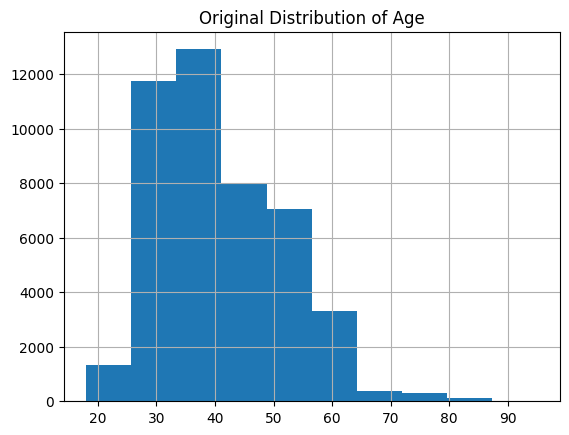

In [66]:
#View the distribution of age
users_data_cleaned['age'].hist()
plt.title('Original Distribution of Age');

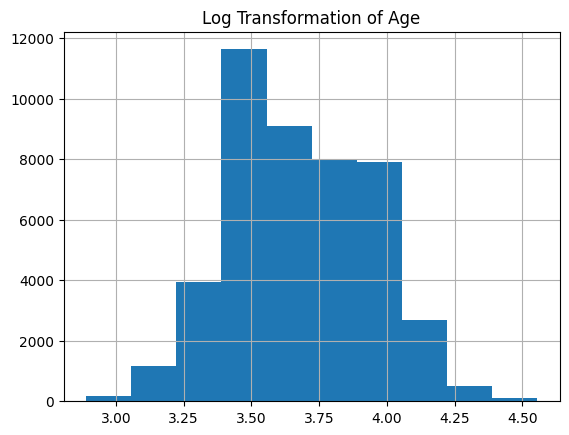

In [67]:
#Apply a log transformation to age
np.log(users_data_cleaned['age']).hist()
plt.title('Log Transformation of Age');

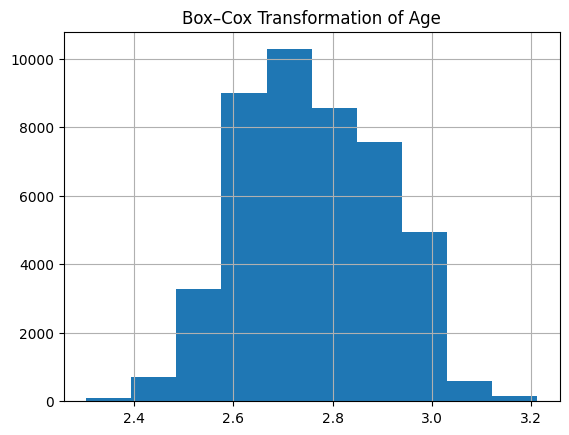

In [68]:
#Apply a Box–Cox transformation to age
pd.Series(stats.boxcox(users_data_cleaned['age'])[0]).hist()
plt.title('Box–Cox Transformation of Age');

In [69]:
#Identify categorical features
categorical_columns = \
list(users_data_cleaned.select_dtypes(['object']).columns)

print('The number of categorical features:',
      len(categorical_columns))
print('The names of categorical features:',
      categorical_columns)

The number of categorical features: 6
The names of categorical features: ['user_id', 'job', 'marital', 'education', 'contact', 'device']


In [70]:
#One-hot encode job
users_data_cleaned.job.value_counts()

job
blue-collar      9725
management       9453
technician       7592
admin.           5168
services         4152
retired          2262
self-employed    1577
entrepreneur     1485
unemployed       1301
housemaid        1239
student           937
Unknown           288
Name: count, dtype: int64

In [71]:
# Create object for one-hot encoding.

encoder = ce.OneHotEncoder(cols = 'job',
                           return_df = True,
                           use_cat_names = True)

In [72]:
# Fit and transform data.

users_data_encoded = encoder.fit_transform(users_data_cleaned)

# Preview the data.

users_data_encoded.head()

,user_id,number_transactions,total_amount_usd,age,job_management,job_technician,job_entrepreneur,job_blue-collar,job_Unknown,job_retired,...,housing,loan,contact,duration,campaign,pdays,previous,term_deposit,date_joined,device
0,9231c446-cb16-4b2b-a7f7-ddfc8b25aaf6,3.0,2143.00,58,1,0,0,0,0,0,...,True,False,Unknown,261,1,-1,0,False,1998-08-23,mobile
1,bb92765a-08de-4963-b432-496524b39157,0.0,1369.42,44,0,1,0,0,0,0,...,True,False,Unknown,151,1,-1,0,False,2008-07-15,desktop
2,573de577-49ef-42b9-83da-d3cfb817b5c1,2.0,2.00,33,0,0,1,0,0,0,...,True,True,Unknown,76,1,-1,0,False,2002-06-04,mobile
3,d6b66b9d-7c8f-4257-a682-e136f640b7e3,0.0,1369.42,47,0,0,0,1,0,0,...,True,False,Unknown,92,1,-1,0,False,1995-06-29,tablet
4,fade0b20-7594-4d9a-84cd-c02f79b1b526,1.0,1.00,33,0,0,0,0,1,0,...,False,False,Unknown,198,1,-1,0,False,1995-08-01,mobile


In [73]:
list(users_data_encoded)

['user_id',
 'number_transactions',
 'total_amount_usd',
 'age',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_Unknown',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'date_joined',
 'device']

In [74]:
print('Shape of data before encoding:',
      users_data_cleaned.shape)
print('Shape of data after encoding:',
      users_data_encoded.shape)

Shape of data before encoding: (45179, 18)
Shape of data after encoding: (45179, 29)


In [75]:
#Dummy encode marital
marital_encoded = \
pd.get_dummies(data = users_data_encoded['marital'],
               drop_first = True,
               dtype = int)

marital_encoded

,married,single
0,1,0
1,0,1
2,1,0
3,1,0
4,0,1
...,...,...
45211,1,0
45212,0,0
45213,1,0
45214,1,0


In [76]:
# Concatenate the new encoded columns.

users_data_encoded = \
pd.concat([users_data_encoded, marital_encoded], axis = 1)

# Drop the original variable.

users_data_encoded.drop(['marital'], axis = 1, inplace = True)

# Preview the data.

users_data_encoded.head()

,user_id,number_transactions,total_amount_usd,age,job_management,job_technician,job_entrepreneur,job_blue-collar,job_Unknown,job_retired,...,contact,duration,campaign,pdays,previous,term_deposit,date_joined,device,married,single
0,9231c446-cb16-4b2b-a7f7-ddfc8b25aaf6,3.0,2143.00,58,1,0,0,0,0,0,...,Unknown,261,1,-1,0,False,1998-08-23,mobile,1,0
1,bb92765a-08de-4963-b432-496524b39157,0.0,1369.42,44,0,1,0,0,0,0,...,Unknown,151,1,-1,0,False,2008-07-15,desktop,0,1
2,573de577-49ef-42b9-83da-d3cfb817b5c1,2.0,2.00,33,0,0,1,0,0,0,...,Unknown,76,1,-1,0,False,2002-06-04,mobile,1,0
3,d6b66b9d-7c8f-4257-a682-e136f640b7e3,0.0,1369.42,47,0,0,0,1,0,0,...,Unknown,92,1,-1,0,False,1995-06-29,tablet,1,0
4,fade0b20-7594-4d9a-84cd-c02f79b1b526,1.0,1.00,33,0,0,0,0,1,0,...,Unknown,198,1,-1,0,False,1995-08-01,mobile,0,1


In [77]:
print('Shape of data after encoding:',
      users_data_encoded.shape)

list(users_data_encoded)

Shape of data after encoding: (45179, 30)


['user_id',
 'number_transactions',
 'total_amount_usd',
 'age',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_Unknown',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'date_joined',
 'device',
 'married',
 'single']

In [78]:
#One-hot encode the remaining categorical variables
cols = ['education', 'contact', 'device']

encoder = ce.OneHotEncoder(cols = cols,
                           return_df = True,
                           use_cat_names = True)

In [79]:
# Fit and transform data.

users_data_encoded = encoder.fit_transform(users_data_encoded)

# Preview the data.

users_data_encoded.head()

,user_id,number_transactions,total_amount_usd,age,job_management,job_technician,job_entrepreneur,job_blue-collar,job_Unknown,job_retired,...,pdays,previous,term_deposit,date_joined,device_mobile,device_desktop,device_tablet,device_Unknown,married,single
0,9231c446-cb16-4b2b-a7f7-ddfc8b25aaf6,3.0,2143.00,58,1,0,0,0,0,0,...,-1,0,False,1998-08-23,1,0,0,0,1,0
1,bb92765a-08de-4963-b432-496524b39157,0.0,1369.42,44,0,1,0,0,0,0,...,-1,0,False,2008-07-15,0,1,0,0,0,1
2,573de577-49ef-42b9-83da-d3cfb817b5c1,2.0,2.00,33,0,0,1,0,0,0,...,-1,0,False,2002-06-04,1,0,0,0,1,0
3,d6b66b9d-7c8f-4257-a682-e136f640b7e3,0.0,1369.42,47,0,0,0,1,0,0,...,-1,0,False,1995-06-29,0,0,1,0,1,0
4,fade0b20-7594-4d9a-84cd-c02f79b1b526,1.0,1.00,33,0,0,0,0,1,0,...,-1,0,False,1995-08-01,1,0,0,0,0,1


In [80]:
print('Shape of data after encoding:',
      users_data_encoded.shape)

list(users_data_encoded)

Shape of data after encoding: (45179, 38)


['user_id',
 'number_transactions',
 'total_amount_usd',
 'age',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_Unknown',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'education_tertiary',
 'education_secondary',
 'education_Unknown',
 'education_primary',
 'default',
 'housing',
 'loan',
 'contact_Unknown',
 'contact_cellular',
 'contact_telephone',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'date_joined',
 'device_mobile',
 'device_desktop',
 'device_tablet',
 'device_Unknown',
 'married',
 'single']

In [81]:
#Discretize age into bins
users_data_encoded.age.describe()

count    45179.000000
mean        40.935103
std         10.618499
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

In [82]:
# Define age bins and labels.

bins = [18, 25, 35, 45, 55, 65, 75, 110]
labels = ['18–24', '25–34', '35–44',
          '45–54', '55–64', '65–74', '75+']

# Perform binning using bin list.

users_data_encoded['age_group'] = \
pd.cut(users_data_encoded['age'], bins = bins,
       labels = labels, right = False)

# Map bins to integer values.
users_data_encoded['age_group_encoded'] = \
users_data_encoded['age_group'].cat.codes

In [83]:
# Verify correct binning.

age_vars = ['age_group_encoded', 'age_group', 'age']

users_data_encoded[age_vars].sample(10)

,age_group_encoded,age_group,age
33564,1,25–34,33
36975,1,25–34,28
42792,3,45–54,52
19170,4,55–64,56
37634,1,25–34,31
3951,1,25–34,32
34320,4,55–64,58
4718,2,35–44,36
41321,1,25–34,28
44008,1,25–34,31


In [84]:
#Plot the new distribution of age
user_age_dist = users_data_encoded.age_group.value_counts()

user_age_dist

age_group
35–44    14524
25–34    14194
45–54     9951
55–64     4892
18–24      809
65–74      510
75+        299
Name: count, dtype: int64

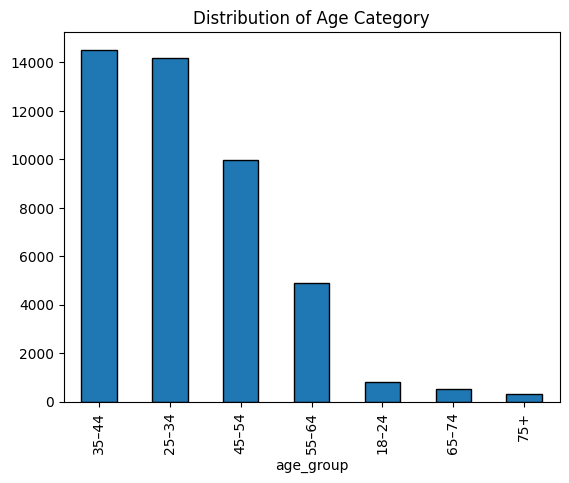

In [85]:
user_age_dist.plot(kind = 'bar', edgecolor = 'black')
plt.title('Distribution of Age Category');

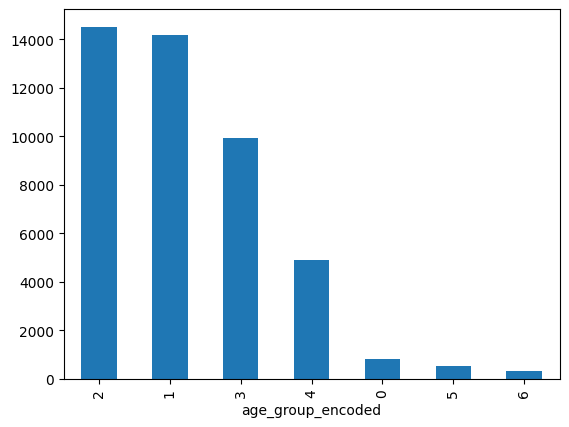

In [86]:
# Check against encoded values.

users_data_encoded.age_group_encoded. \
value_counts().plot(kind = 'bar');

In [87]:
#Drop the age and age_group variables
users_data_encoded.drop(['age', 'age_group'],
                        axis = 1, inplace = True)

list(users_data_encoded)

['user_id',
 'number_transactions',
 'total_amount_usd',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_Unknown',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'education_tertiary',
 'education_secondary',
 'education_Unknown',
 'education_primary',
 'default',
 'housing',
 'loan',
 'contact_Unknown',
 'contact_cellular',
 'contact_telephone',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'date_joined',
 'device_mobile',
 'device_desktop',
 'device_tablet',
 'device_Unknown',
 'married',
 'single',
 'age_group_encoded']

In [88]:
#Create a month_joined variable from date_joined
users_data_encoded['month_joined'] = \
users_data_encoded.date_joined.dt.month

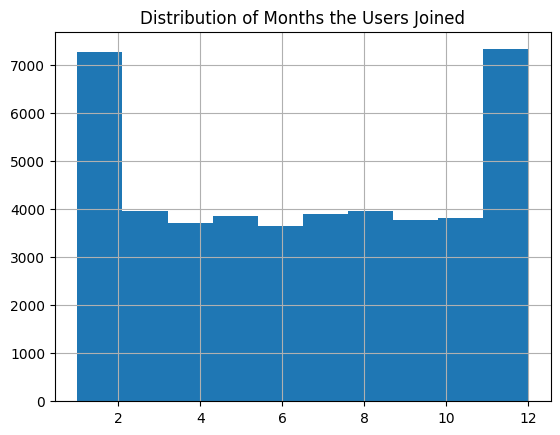

In [89]:
# View the distribution of data.

users_data_encoded['month_joined'].hist()
plt.title('Distribution of Months the Users Joined');

In [90]:
#Drop date_joined
users_data_encoded.drop(['date_joined'],
                        axis = 1, inplace = True)

list(users_data_encoded)

['user_id',
 'number_transactions',
 'total_amount_usd',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_Unknown',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'education_tertiary',
 'education_secondary',
 'education_Unknown',
 'education_primary',
 'default',
 'housing',
 'loan',
 'contact_Unknown',
 'contact_cellular',
 'contact_telephone',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'device_mobile',
 'device_desktop',
 'device_tablet',
 'device_Unknown',
 'married',
 'single',
 'age_group_encoded',
 'month_joined']

In [91]:
#Remove features with low variance
users_data_encoded.std(numeric_only = True)

number_transactions       3.749994
total_amount_usd       2704.291321
job_management            0.406767
job_technician            0.373908
job_entrepreneur          0.178296
job_blue-collar           0.411004
job_Unknown               0.079587
job_retired               0.218087
job_admin.                0.318287
job_services              0.288889
job_self-employed         0.183543
job_unemployed            0.167236
job_housemaid             0.163318
job_student               0.142513
education_tertiary        0.455691
education_secondary       0.499832
education_Unknown         0.198480
education_primary         0.358591
default                   0.133095
housing                   0.496878
loan                      0.366802
contact_Unknown           0.452851
contact_cellular          0.477695
contact_telephone         0.245250
duration                257.281109
campaign                  3.097836
pdays                   100.134967
previous                  2.303009
term_deposit        

In [92]:
# Define standard deviation threshold.

threshold = 0.1

# Identify features below threshold.

cols_to_drop = \
list(users_data_encoded. \
     std(numeric_only = True)[users_data_encoded. \
                              std(numeric_only = True) \
                              < threshold].index.values)

print('Features with low standard deviation:',
      cols_to_drop)

Features with low standard deviation: ['job_Unknown', 'device_Unknown']


In [93]:
# Drop features below threshold.

users_data_interim = users_data_encoded.drop(cols_to_drop,
                                             axis = 1)

list(users_data_interim)

['user_id',
 'number_transactions',
 'total_amount_usd',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'education_tertiary',
 'education_secondary',
 'education_Unknown',
 'education_primary',
 'default',
 'housing',
 'loan',
 'contact_Unknown',
 'contact_cellular',
 'contact_telephone',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'device_mobile',
 'device_desktop',
 'device_tablet',
 'married',
 'single',
 'age_group_encoded',
 'month_joined']

In [94]:
#Drop highly correlated features
# Define correlation threshold.

threshold = 0.75

corr_matrix = users_data_encoded.corr(numeric_only = True).abs()
high_corr_var = np.where(corr_matrix >= threshold)
high_corr_var = [(corr_matrix.index[x],
                  corr_matrix.columns[y],
                  round(corr_matrix.iloc[x, y], 2))
                  for x, y in zip(*high_corr_var)
                  if x != y and x < y]


high_corr_var

[('contact_Unknown', 'contact_cellular', np.float64(0.86)),
 ('device_mobile', 'device_desktop', np.float64(0.75)),
 ('married', 'single', np.float64(0.77))]

In [95]:
# Tidy up the output.

record_collinear = pd.DataFrame(high_corr_var). \
rename(columns = {0: 'drop_feature',
                  1: 'corr_feature',
                  2: 'corr_values'})

record_collinear = record_collinear. \
sort_values(by = 'corr_values', ascending = False)

record_collinear = record_collinear.reset_index(drop = True)

record_collinear 

,drop_feature,corr_feature,corr_values
0,contact_Unknown,contact_cellular,0.86
1,married,single,0.77
2,device_mobile,device_desktop,0.75


In [96]:
cols_to_drop = list(record_collinear['drop_feature'])
print(cols_to_drop)

['contact_Unknown', 'married', 'device_mobile']


In [97]:
users_data_final = users_data_interim.drop(cols_to_drop,
                                           axis = 1)

list(users_data_final)

['user_id',
 'number_transactions',
 'total_amount_usd',
 'job_management',
 'job_technician',
 'job_entrepreneur',
 'job_blue-collar',
 'job_retired',
 'job_admin.',
 'job_services',
 'job_self-employed',
 'job_unemployed',
 'job_housemaid',
 'job_student',
 'education_tertiary',
 'education_secondary',
 'education_Unknown',
 'education_primary',
 'default',
 'housing',
 'loan',
 'contact_cellular',
 'contact_telephone',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'term_deposit',
 'device_desktop',
 'device_tablet',
 'single',
 'age_group_encoded',
 'month_joined']

In [98]:
#Filter by demographics data
users_data_demographics = \
users_data_final.filter(regex = 'education|job|age|single')

users_data_demographics.head(n = 3)

,job_management,job_technician,job_entrepreneur,job_blue-collar,job_retired,job_admin.,job_services,job_self-employed,job_unemployed,job_housemaid,job_student,education_tertiary,education_secondary,education_Unknown,education_primary,single,age_group_encoded
0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4
1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,2
2,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1


In [99]:
#Standardize the demographics data
users_data_demographics.describe()

,job_management,job_technician,job_entrepreneur,job_blue-collar,job_retired,job_admin.,job_services,job_self-employed,job_unemployed,job_housemaid,job_student,education_tertiary,education_secondary,education_Unknown,education_primary,single,age_group_encoded
count,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000,45179.000000
mean,0.209234,0.168043,0.032869,0.215255,0.050068,0.114389,0.091901,0.034906,0.028797,0.027424,0.020740,0.294207,0.513159,0.041081,0.151553,0.282897,2.147170
std,0.406767,0.373908,0.178296,0.411004,0.218087,0.318287,0.288889,0.183543,0.167236,0.163318,0.142513,0.455691,0.499832,0.198480,0.358591,0.450412,1.106811
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000


In [100]:
scaler = StandardScaler()
        
scaler.fit(users_data_demographics)
users_data_scaled = scaler.transform(users_data_demographics)

print('New standard deviation: ', users_data_scaled.std())
print('New mean:               ', round(users_data_scaled.mean()))

New standard deviation:  1.0
New mean:                0


In [101]:
#Perform PCA to reduce the dimensionality of the demographics dataset
pca = PCA(n_components = 2, random_state = 1)

pca.fit(users_data_scaled)

reduced = pca.transform(users_data_scaled)

In [102]:
reduced_df = pd.DataFrame(reduced, columns = ['PCA1', 'PCA2'])

reduced_df

,PCA1,PCA2
0,2.555464,1.080715
1,-0.818581,-1.751929
2,-0.572830,-0.553687
3,-0.546107,1.596294
4,0.385254,-0.614489
...,...,...
45174,1.159487,0.074663
45175,-0.656264,4.368307
45176,-1.324414,2.365734
45177,-1.577706,1.041209


In [103]:
#Load the final dataset
users_data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45179 entries, 0 to 45215
Data columns (total 33 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              45179 non-null  object 
 1   number_transactions  45179 non-null  float64
 2   total_amount_usd     45179 non-null  float64
 3   job_management       45179 non-null  int64  
 4   job_technician       45179 non-null  int64  
 5   job_entrepreneur     45179 non-null  int64  
 6   job_blue-collar      45179 non-null  int64  
 7   job_retired          45179 non-null  int64  
 8   job_admin.           45179 non-null  int64  
 9   job_services         45179 non-null  int64  
 10  job_self-employed    45179 non-null  int64  
 11  job_unemployed       45179 non-null  int64  
 12  job_housemaid        45179 non-null  int64  
 13  job_student          45179 non-null  int64  
 14  education_tertiary   45179 non-null  int64  
 15  education_secondary  45179 non-null  int6

In [104]:
reduced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45179 entries, 0 to 45178
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PCA1    45179 non-null  float64
 1   PCA2    45179 non-null  float64
dtypes: float64(2)
memory usage: 706.1 KB


In [105]:
users_data_final.to_pickle('users_data_final.pickle')

In [106]:
#Load the demographics dataset with PCA applied
reduced_df.to_pickle('users_data_demo_pca.pickle')